# Exercícios 1.1 e 1.2 — Disponibilidade de Serviço Replicado

**Parâmetros do problema:**
- `n` — número de servidores (n > 0)
- `k` — número mínimo de servidores disponíveis para o serviço funcionar (0 < k ≤ n)
- `p` — probabilidade de cada servidor estar disponível em um dado instante (0 ≤ p ≤ 1)

---
## Exercício 1.1 — Derivação da Fórmula

### Passo 1: Modelagem do problema

Cada servidor é **independente** e fica disponível com probabilidade `p`.  
Logo, o número de servidores disponíveis em um instante qualquer é uma variável aleatória:

$$X \sim \text{Binomial}(n, p)$$

---

### Passo 2: O que queremos calcular?

O serviço está disponível quando **pelo menos k servidores** estão no ar:

$$A(n, k, p) = P(X \geq k)$$

---

### Passo 3: Expandindo com a distribuição binomial

A probabilidade de exatamente `i` servidores estarem disponíveis é:

$$P(X = i) = \binom{n}{i} \cdot p^i \cdot (1-p)^{n-i}$$

Onde $\binom{n}{i} = \frac{n!}{i!(n-i)!}$ é o número de maneiras de escolher `i` servidores dentre `n`.

Somando para todos os valores de `i` de `k` até `n`:

$$\boxed{A(n, k, p) = \sum_{i=k}^{n} \binom{n}{i} \cdot p^i \cdot (1-p)^{n-i}}$$

---

### Passo 4: Casos extremos

**Caso k = 1 (operação de consulta):** o serviço funciona se ao menos 1 servidor está no ar.  
Mais fácil via complemento — probabilidade de **nenhum** servidor estar disponível:

$$A(n, 1, p) = 1 - P(X = 0) = 1 - (1-p)^n$$

**Caso k = n (operação de atualização):** o serviço só funciona se **todos** os servidores estão disponíveis:

$$A(n, n, p) = P(X = n) = p^n$$

**Intuição:** consultas são mais tolerantes a falhas (basta 1 servidor), enquanto atualizações exigem consenso total — por isso replicação ajuda consultas mas prejudica atualizações.

# Explicação da Fórmula de Disponibilidade

## Fórmula

$$A(n, k, p) = \sum_{i=k}^{n} \binom{n}{i} \cdot p^i \cdot (1 - p)^{n - i}$$

---

## O que a fórmula calcula

Calcula a **probabilidade de pelo menos $k$ servidores estarem funcionando**, dado que:

| Parâmetro | Significado |
|-----------|-------------|
| $n$ | Número total de servidores |
| $k$ | Número mínimo necessário funcionando |
| $p$ | Probabilidade de cada servidor individual estar operacional |

Trata-se de uma aplicação direta da **distribuição binomial acumulada** (*survival function*), sob a premissa de que as falhas dos servidores são **independentes e identicamente distribuídas** (i.i.d.).

---

## Explicação de cada parte

### $A(n, k, p)$

Representa a **disponibilidade do sistema**, ou seja, a probabilidade de o sistema estar operacional.

### $\displaystyle\sum_{i=k}^{n}$

Indica que somamos todos os cenários favoráveis: desde exatamente $k$ servidores funcionando até todos os $n$. Qualquer um desses cenários satisfaz o requisito mínimo.

### $\displaystyle\binom{n}{i}$

É o **coeficiente binomial** — o número de formas distintas de escolher quais $i$ servidores (dentre $n$) estão funcionando.

$$\binom{n}{i} = \frac{n!}{i!(n - i)!}$$

### $p^i$

Probabilidade de $i$ servidores **específicos** estarem funcionando simultaneamente. Como as falhas são independentes, as probabilidades se multiplicam.

### $(1 - p)^{n - i}$

Probabilidade de os $n - i$ servidores restantes estarem **falhando**. Cada um falha com probabilidade $q = 1 - p$.

---

## O que cada termo completo representa

$$\binom{n}{i} \cdot p^i \cdot (1 - p)^{n - i}$$

É a probabilidade de **exatamente** $i$ servidores estarem operacionais — ou seja, o termo $P(X = i)$ da distribuição binomial $X \sim \text{Binomial}(n, p)$.

---

## Interpretação final

A fórmula agrega todas as probabilidades em que o número de servidores funcionando é $\geq k$:

$$A(n, k, p) = P(X \geq k) = 1 - \sum_{i=0}^{k-1} \binom{n}{i} \cdot p^i \cdot (1 - p)^{n - i}$$

Essa forma complementar ($1 - P(X < k)$) é computacionalmente útil quando $k$ é grande em relação a $n$.

---
## Importações

In [11]:
import math               # funções matemáticas básicas: log, ceil (usadas no estudo complementar)
import numpy as np        # arrays e operações vetorizadas (amostras Monte Carlo, linspace, etc.)
import pandas as pd       # DataFrames: organização e exibição tabular dos resultados
import matplotlib.pyplot as plt  # geração de gráficos (linhas, barras, heatmaps, scatter)
from scipy.stats import binom    # distribuição binomial: binom.sf calcula P(X >= k) com precisão numérica

# Configurações globais de estilo para todos os gráficos do notebook
plt.rcParams['figure.figsize'] = (12, 5)  # tamanho padrão (largura x altura em polegadas)
plt.rcParams['axes.grid'] = True           # grade habilitada por padrão
plt.rcParams['grid.alpha'] = 0.3           # grade semitransparente para não poluir visualmente


---
## Exercício 1.2 — Parte 1: Cálculo Analítico

In [12]:
def disponibilidade_analitica(n: int, k: int, p: float) -> float:
    """
    Calcula A(n,k,p) = P(X >= k) onde X ~ Binomial(n, p).

    Usa binom.sf(k-1, n, p) que é a Survival Function = 1 - CDF(k-1),
    equivalente a somar C(n,i)*p^i*(1-p)^(n-i) para i de k até n.
    """
    return float(binom.sf(k - 1, n, p))


def disponibilidade_k1(n: int, p: float) -> float:
    """Caso extremo k=1: A = 1 - (1-p)^n"""
    return 1.0 - (1.0 - p) ** n


def disponibilidade_kn(n: int, p: float) -> float:
    """Caso extremo k=n: A = p^n"""
    return p ** n


# Verificação: fórmula geral deve bater com casos extremos
print("=== Verificação da fórmula ===")
for n, k, p in [(3,1,0.9), (3,2,0.9), (3,3,0.9), (5,1,0.8), (5,5,0.8)]:
    print(f"  n={n}, k={k}, p={p} → A={disponibilidade_analitica(n,k,p):.6f}")

print()
print("Casos extremos vs fórmula geral (devem ser iguais):")
n, p = 5, 0.8
print(f"  k=1 : geral={disponibilidade_analitica(n,1,p):.6f} | 1-(1-p)^n={disponibilidade_k1(n,p):.6f}")
print(f"  k=n : geral={disponibilidade_analitica(n,n,p):.6f} | p^n       ={disponibilidade_kn(n,p):.6f}")

=== Verificação da fórmula ===
  n=3, k=1, p=0.9 → A=0.999000
  n=3, k=2, p=0.9 → A=0.972000
  n=3, k=3, p=0.9 → A=0.729000
  n=5, k=1, p=0.8 → A=0.999680
  n=5, k=5, p=0.8 → A=0.327680

Casos extremos vs fórmula geral (devem ser iguais):
  k=1 : geral=0.999680 | 1-(1-p)^n=0.999680
  k=n : geral=0.327680 | p^n       =0.327680


### Tabela — Disponibilidade para diferentes valores de n, k e p

In [13]:
n_values = [1, 3, 5, 7, 10]
p_values = [0.5, 0.7, 0.9, 0.95, 0.99]

rows = []
for n in n_values:
    for p in p_values:
        k_maioria = n // 2 + 1
        rows.append({
            'n': n,
            'k_maioria': k_maioria,
            'p': p,
            'k=1 (consulta)': round(disponibilidade_analitica(n, 1, p), 6),
            'k=maioria': round(disponibilidade_analitica(n, k_maioria, p), 6),
            'k=n (atualiz.)': round(disponibilidade_analitica(n, n, p), 6),
        })

df_analitico = pd.DataFrame(rows)
pd.set_option('display.float_format', '{:.6f}'.format)
pd.set_option('display.max_rows', 40)
display(df_analitico)

,n,k_maioria,p,k=1 (consulta),k=maioria,k=n (atualiz.)
0,1,1,0.500000,0.500000,0.500000,0.500000
1,1,1,0.700000,0.700000,0.700000,0.700000
2,1,1,0.900000,0.900000,0.900000,0.900000
3,1,1,0.950000,0.950000,0.950000,0.950000
4,1,1,0.990000,0.990000,0.990000,0.990000
5,3,2,0.500000,0.875000,0.500000,0.125000
6,3,2,0.700000,0.973000,0.784000,0.343000
7,3,2,0.900000,0.999000,0.972000,0.729000
8,3,2,0.950000,0.999875,0.992750,0.857375
9,3,2,0.990000,0.999999,0.999702,0.970299


**Tabela 1** — Disponibilidade analítica em diferentes configurações do sistema. *Fonte: elaboração própria.*

A tabela cobre todas as combinações entre cinco tamanhos de sistema (n = 1, 3, 5, 7, 10) e cinco probabilidades individuais de disponibilidade (p = 0,5; 0,7; 0,9; 0,95; 0,99). Para cada par (n, p), três métricas são exibidas:

**k = 1 (consulta):** basta um único servidor ativo para o serviço operar. É o cenário menos restritivo e, por isso, apresenta os maiores valores de disponibilidade.

**k = maioria** (⌊n/2⌋ + 1): exige que a maioria dos servidores esteja disponível ao mesmo tempo. Representa um equilíbrio entre tolerância a falhas e exigência de consenso.

**k = n (atualização):** todos os servidores precisam estar ativos simultaneamente. É o cenário mais restritivo e, portanto, apresenta os menores valores de disponibilidade.

Os valores são calculados por `disponibilidade_analitica(n, k, p)` e arredondados para 6 casas decimais.

### Gráfico 1 — Disponibilidade em função de p (com n fixo)

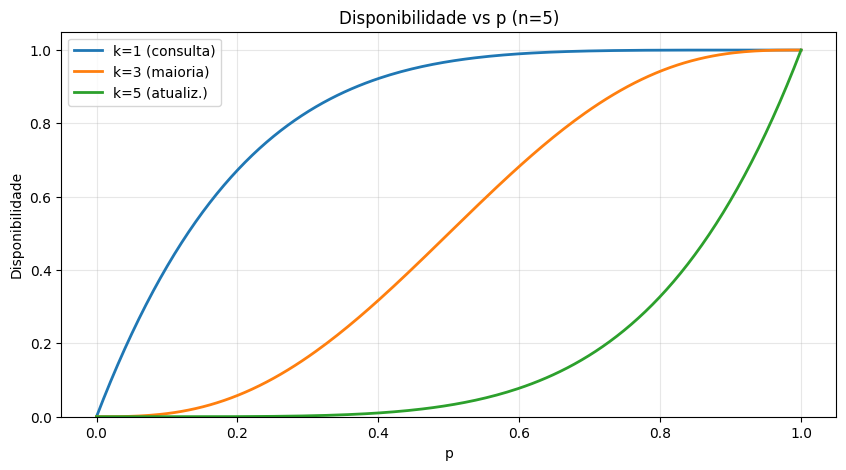

In [14]:
p_range = np.linspace(0, 1, 200)
n_fixed = 5
k_maioria = n_fixed // 2 + 1

plt.figure(figsize=(10, 5))

for k, label in [
    (1, 'k=1 (consulta)'),
    (k_maioria, f'k={k_maioria} (maioria)'),
    (n_fixed, f'k={n_fixed} (atualiz.)')
]:
    A = [disponibilidade_analitica(n_fixed, k, p) for p in p_range]
    plt.plot(p_range, A, lw=2, label=label)

plt.title(f'Disponibilidade vs p (n={n_fixed})')
plt.xlabel('p')
plt.ylabel('Disponibilidade')
plt.ylim(0, 1.05)
plt.legend()
plt.show()

**Figura 1** — Variação da disponibilidade em função de p para n = 5. *Fonte: elaboração própria.*

O gráfico traça três curvas para um sistema com n = 5 servidores, varrendo p de 0 a 1. O eixo x representa p, a probabilidade individual de disponibilidade de cada servidor; o eixo y representa a disponibilidade total do sistema A(n, k, p).

À medida que p cresce, todas as curvas sobem — mas em ritmos distintos. A curva **k = 1** já parte de valores elevados mesmo com p baixo, pois basta qualquer servidor estar no ar. A curva **k = 3 (maioria)** exige consenso entre a maioria dos nós, então cresce de forma mais gradual. A curva **k = 5 (atualização)** é a mais sensível a falhas individuais: pequenas quedas em p reduzem rapidamente a disponibilidade do sistema, pois todos os servidores precisam estar ativos.

### Gráfico 2 — Heatmap de disponibilidade (n × p) para cada política de quorum

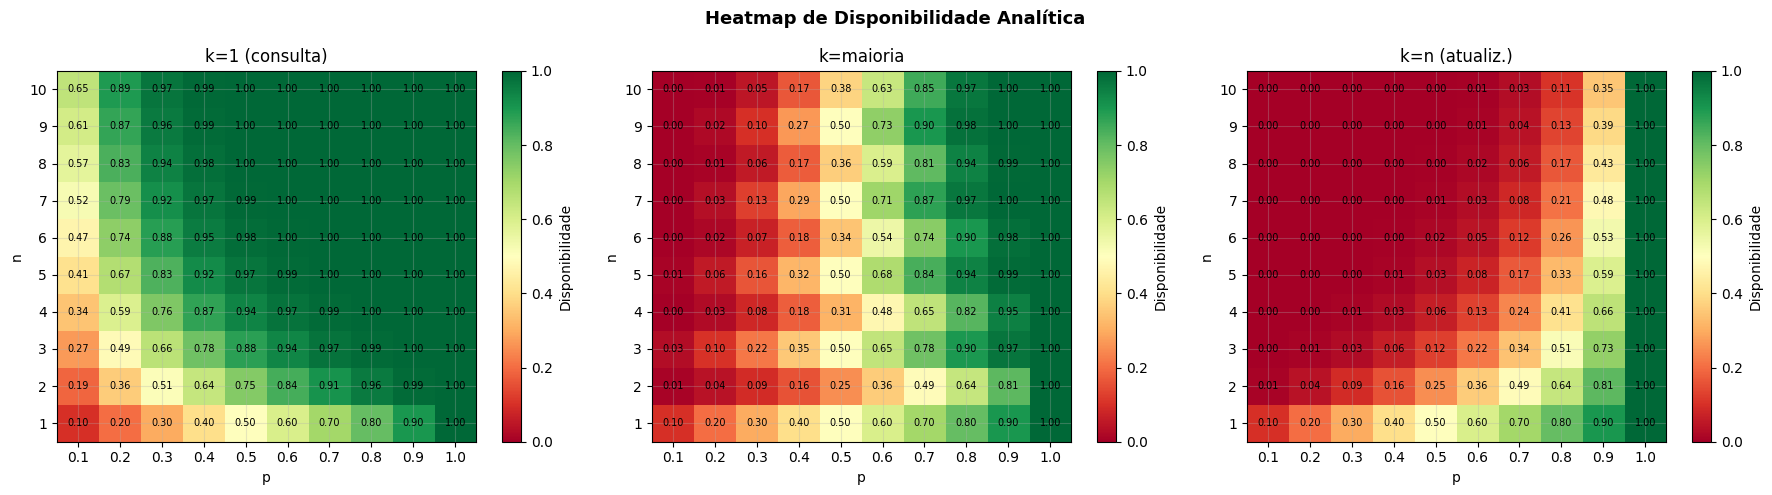

In [15]:
n_vals = list(range(1, 11))
p_vals = np.round(np.linspace(0.1, 1.0, 10), 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
titles = ['k=1 (consulta)', 'k=maioria', 'k=n (atualiz.)']

for ax, title in zip(axes, titles):
    matrix = []
    for n in n_vals:
        row = []
        for p in p_vals:
            if 'k=1' in title:
                k = 1
            elif 'maioria' in title:
                k = n // 2 + 1
            else:
                k = n
            row.append(disponibilidade_analitica(n, k, p))
        matrix.append(row)

    matrix = np.array(matrix)
    im = ax.imshow(matrix, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1, origin='lower')
    ax.set_xticks(range(len(p_vals))); ax.set_xticklabels([f'{p:.1f}' for p in p_vals])
    ax.set_yticks(range(len(n_vals))); ax.set_yticklabels(n_vals)
    ax.set_xlabel('p'); ax.set_ylabel('n'); ax.set_title(title)
    for i in range(len(n_vals)):
        for j in range(len(p_vals)):
            ax.text(j, i, f'{matrix[i,j]:.2f}', ha='center', va='center', fontsize=7)
    plt.colorbar(im, ax=ax, label='Disponibilidade')

plt.suptitle('Heatmap de Disponibilidade Analítica', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Figura 2** — Heatmaps da disponibilidade analítica para diferentes valores de n e p. *Fonte: elaboração própria.*

Cada heatmap exibe uma grade onde as colunas representam valores de p (0,1 a 1,0) e as linhas representam n (1 a 10). Cada célula é colorida pelo valor de disponibilidade calculado — tons verdes indicam alta disponibilidade e tons vermelhos indicam baixa. O valor numérico aparece dentro de cada célula para leitura precisa.

Os três painéis correspondem aos critérios de quórum k = 1 (consulta), k = maioria e k = n (atualização). A comparação entre eles deixa clara a influência do quórum: no painel **k = 1** quase toda a grade é verde, pois qualquer nó ativo sustenta o serviço; no painel **k = n** o vermelho domina especialmente para n alto e p baixo, pois a probabilidade de todos os servidores estarem simultaneamente no ar cai exponencialmente com n.

---
## Exercício 1.2 — Parte 2: Simulador Estocástico

**Lógica de cada rodada:**
1. Para cada servidor, gera `U ~ Uniform(0,1)`
2. O servidor está disponível se `U <= p`
3. Conta quantos estão disponíveis
4. Serviço operacional se `count >= k`

A disponibilidade experimental é a proporção de rodadas bem-sucedidas.

In [16]:
def simular_disponibilidade(n: int, k: int, p: float, rodadas: int, seed: int = 42) -> float:
    """
    Simulador Monte Carlo para disponibilidade de serviço replicado.

    - Gera matriz (rodadas × n) de amostras U(0,1)
    - Servidor disponível se amostra <= p
    - Serviço operacional se soma de disponíveis >= k
    - Retorna proporção de rodadas operacionais
    """
    rng = np.random.default_rng(seed)
    amostras    = rng.random((rodadas, n))      # shape (rodadas, n)
    disponiveis = amostras <= p                  # bool: servidor disponível?
    contagem    = disponiveis.sum(axis=1)        # servidores disponíveis por rodada
    operacional = contagem >= k                  # serviço no ar?
    return float(operacional.mean())             # frequência experimental


# Verificação: deve ficar próximo do analítico
print("=== Verificação do simulador (100k rodadas) ===")
for n, k, p in [(3,1,0.9), (3,2,0.9), (3,3,0.9), (5,3,0.8), (10,5,0.7)]:
    sim  = simular_disponibilidade(n, k, p, rodadas=100_000)
    real = disponibilidade_analitica(n, k, p)
    print(f"  n={n}, k={k}, p={p} → Simulado={sim:.5f} | Analítico={real:.5f} | Δ={abs(sim-real):.5f}")

=== Verificação do simulador (100k rodadas) ===
  n=3, k=1, p=0.9 → Simulado=0.99902 | Analítico=0.99900 | Δ=0.00002
  n=3, k=2, p=0.9 → Simulado=0.97144 | Analítico=0.97200 | Δ=0.00056
  n=3, k=3, p=0.9 → Simulado=0.72897 | Analítico=0.72900 | Δ=0.00003
  n=5, k=3, p=0.8 → Simulado=0.94198 | Analítico=0.94208 | Δ=0.00010
  n=10, k=5, p=0.7 → Simulado=0.95307 | Analítico=0.95265 | Δ=0.00042


### Análise de Convergência — Quantas rodadas são suficientes?

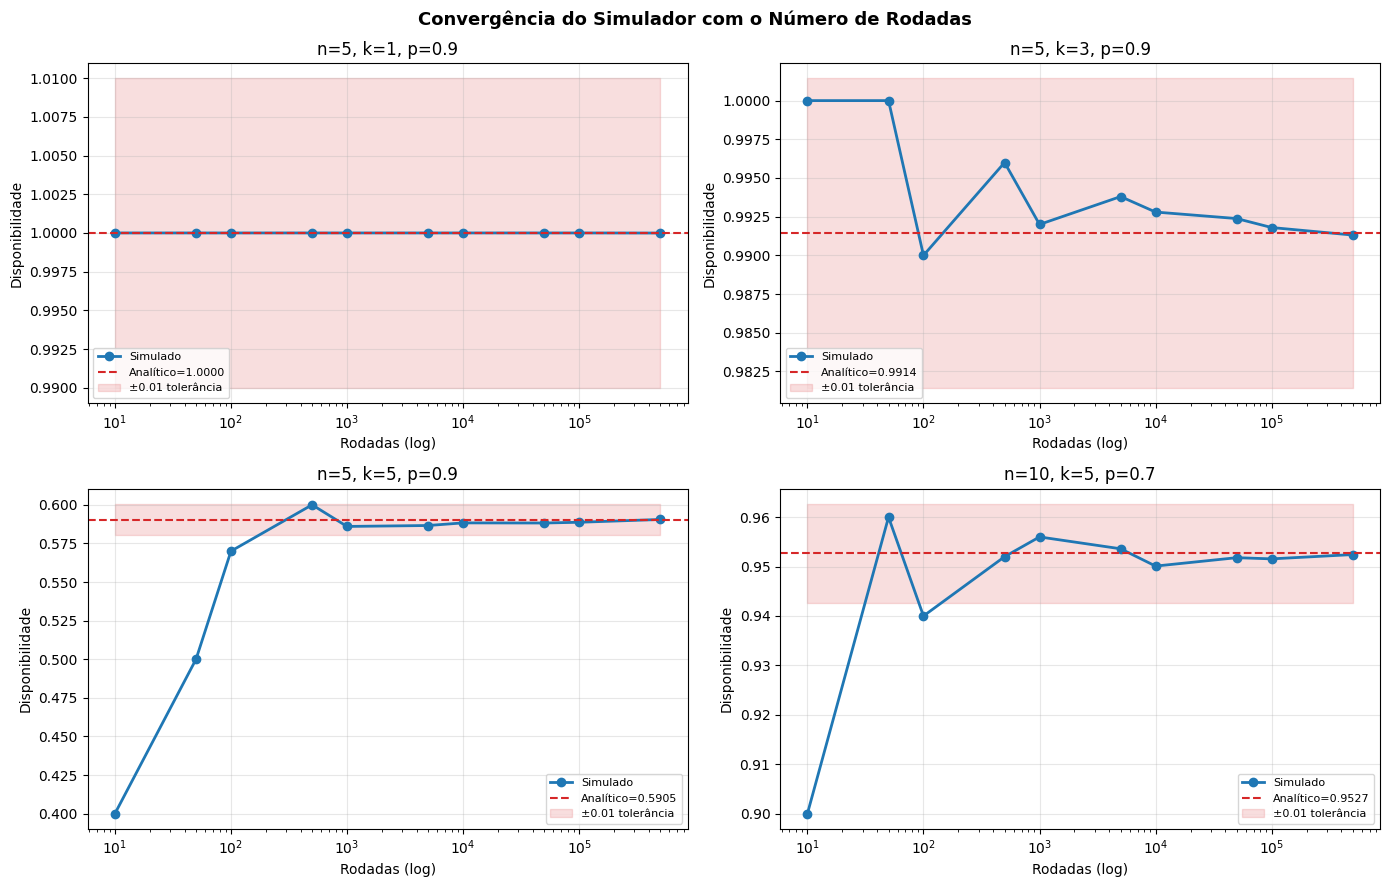

In [17]:
rodadas_range = [10, 50, 100, 500, 1_000, 5_000, 10_000, 50_000, 100_000, 500_000]

# Cenários escolhidos para cobrir casos de disponibilidade alta, intermediária e baixa
cenarios = [
    (5, 1, 0.9, 'n=5, k=1, p=0.9'),
    (5, 3, 0.9, 'n=5, k=3, p=0.9'),
    (5, 5, 0.9, 'n=5, k=5, p=0.9'),
    (10, 5, 0.7, 'n=10, k=5, p=0.7'),
]

convergencia = {}
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()  # transforma a grade 2×2 em lista de 4 axes para iterar facilmente

for idx, (n, k, p, label) in enumerate(cenarios):
    real = disponibilidade_analitica(n, k, p)  # valor de referência (analítico exato)
    resultados, erros = [], []
    for r in rodadas_range:
        # seed diferente a cada cenário para garantir independência entre as simulações
        sim = simular_disponibilidade(n, k, p, rodadas=r, seed=idx * 7 + 13)
        resultados.append(sim)
        erros.append(abs(sim - real))  # erro absoluto entre simulado e analítico
    convergencia[label] = {'rodadas': rodadas_range, 'sim': resultados, 'erro': erros, 'real': real}

    ax = axes[idx]
    # semilogx: eixo x em escala logarítmica para comprimir a faixa 10–500.000 visivelmente
    ax.semilogx(rodadas_range, resultados, 'o-', color='tab:blue', lw=2, label='Simulado')
    ax.axhline(real, ls='--', color='tab:red', lw=1.5, label=f'Analítico={real:.4f}')
    # fill_between: faixa sombreada de ±0.01 ao redor do valor exato (tolerância de 1%)
    ax.fill_between(rodadas_range, [real - 0.01]*len(rodadas_range),
                    [real + 0.01]*len(rodadas_range),
                    alpha=0.15, color='tab:red', label='±0.01 tolerância')
    ax.set_title(label)
    ax.set_xlabel('Rodadas (log)')
    ax.set_ylabel('Disponibilidade')
    ax.legend(fontsize=8)

plt.suptitle('Convergência do Simulador com o Número de Rodadas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Gráfico de Convergência — Escala Log-Log (Erro vs Rodadas)

O gráfico seguinte exibe o **erro absoluto** `|Simulado − Analítico|` em escala **log-log**.

A escala log-log é escolhida porque o erro do método Monte Carlo decai como $\varepsilon \approx 1/\sqrt{R}$, onde $R$ é o número de rodadas. Nessa escala, essa relação aparece como uma **reta de inclinação −½**, tornando imediata a verificação de que o simulador converge conforme o esperado teórico.

A linha pontilhada preta marca a referência teórica `1/√R`. Curvas próximas a ela confirmam o comportamento Monte Carlo padrão. As linhas horizontais tracejadas marcam tolerâncias de **1%** e **0,1%** — limiares práticos para decidir quando o número de rodadas já é suficiente.

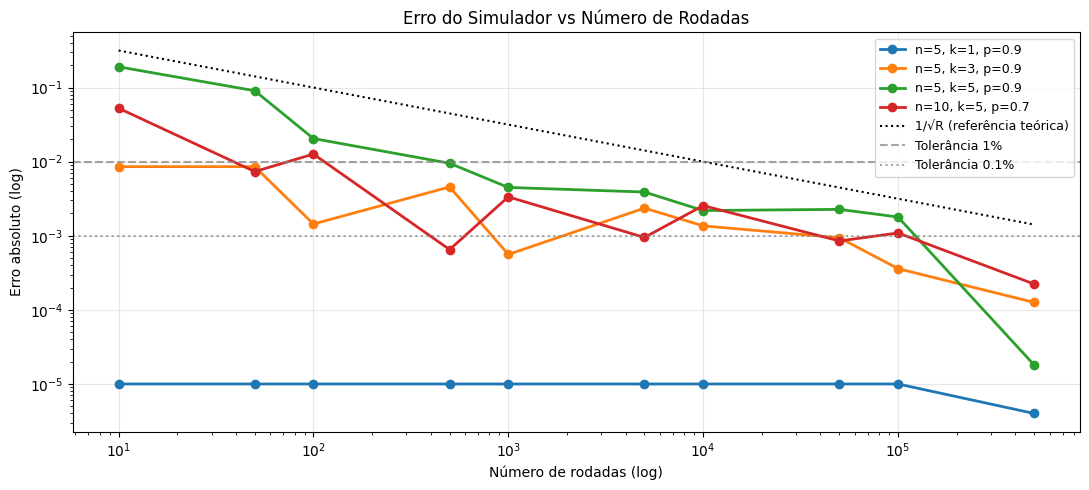

In [18]:
# Gráfico de erro absoluto em escala log-log
# Em escala log-log, a relação erro ∝ 1/√R torna-se uma reta de inclinação -½,
# o que facilita identificar se o simulador converge conforme o esperado teórico
fig, ax = plt.subplots(figsize=(11, 5))
cores = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']
for (label, data), cor in zip(convergencia.items(), cores):
    ax.loglog(data['rodadas'], data['erro'], 'o-', label=label, color=cor, lw=2)

# Referência teórica: em Monte Carlo o erro padrão é σ/√R ≈ 1/√R (com σ ≤ 1 para proporções)
ref = np.array(rodadas_range, dtype=float)
ax.loglog(ref, 1.0 / np.sqrt(ref), 'k:', lw=1.5, label='1/√R (referência teórica)')

# Limiares práticos: 1% e 0.1% de erro absoluto
ax.axhline(0.01,  ls='--', color='gray', alpha=0.7, label='Tolerância 1%')
ax.axhline(0.001, ls=':',  color='gray', alpha=0.7, label='Tolerância 0.1%')

ax.set_xlabel('Número de rodadas (log)')
ax.set_ylabel('Erro absoluto (log)')
ax.set_title('Erro do Simulador vs Número de Rodadas')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

### Tabela de Erro Absoluto por Número de Rodadas

A tabela abaixo usa `pivot_table` para reorganizar os erros absolutos: cada **linha** é um número de rodadas e cada **coluna** é um cenário.

Isso permite comparar, de uma só vez, como o erro de cada cenário evolui conforme aumentamos `R`.

> **Coloração:** tons mais escuros (amarelo → vermelho) indicam erros maiores; tons claros indicam erros próximos de zero.

In [19]:
# Tabela de erro por número de rodadas
rows_conv = []
for label, data in convergencia.items():
    for r, sim, err in zip(data['rodadas'], data['sim'], data['erro']):
        rows_conv.append({'Cenário': label, 'Rodadas': r,
                          'Simulado': round(sim, 5), 'Analítico': round(data['real'], 5),
                          'Erro Abs.': round(err, 5)})

df_conv = pd.DataFrame(rows_conv)
df_pivot = df_conv.pivot_table(index='Rodadas', columns='Cenário', values='Erro Abs.')
display(df_pivot.round(5))

Cenário,"n=10, k=5, p=0.7","n=5, k=1, p=0.9","n=5, k=3, p=0.9","n=5, k=5, p=0.9"
Rodadas,,,,
10,0.052650,0.000010,0.008560,0.190490
50,0.007350,0.000010,0.008560,0.090490
100,0.012650,0.000010,0.001440,0.020490
500,0.000650,0.000010,0.004560,0.009510
1000,0.003350,0.000010,0.000560,0.004490
5000,0.000950,0.000010,0.002360,0.003890
10000,0.002550,0.000010,0.001360,0.002190
50000,0.000850,0.000010,0.000940,0.002270
100000,0.001090,0.000010,0.000360,0.001790


---
## Análise Comparativa — Simulador vs Analítico

In [20]:
RODADAS = 100_000
n_list = [3, 5, 7, 10]
p_list = [0.5, 0.7, 0.9, 0.95, 0.99]

rows_comp = []
for n in n_list:
    for p in p_list:
        casos = [
            ('k=1',      1),
            ('k=maioria', n // 2 + 1),
            ('k=n',      n)
        ]
        for nome_k, k in casos:
            analitico = disponibilidade_analitica(n, k, p)
            simulado  = simular_disponibilidade(n, k, p, RODADAS)
            rows_comp.append({
                'n': n, 'k_tipo': nome_k, 'k': k, 'p': p,
                'Analítico':  round(analitico, 6),
                'Simulado':   round(simulado, 6),
                'Erro Abs.':  round(abs(analitico - simulado), 6),
                # max(..., 1e-9): evita divisão por zero quando a disponibilidade analítica é 0
                'Erro Rel.%': round(abs(analitico - simulado) / max(analitico, 1e-9) * 100, 3),
            })

df_comp = pd.DataFrame(rows_comp)
print(f'=== Comparação Analítico vs Simulador ({RODADAS:,} rodadas) ===')
df_comp

=== Comparação Analítico vs Simulador (100,000 rodadas) ===


,n,k_tipo,k,p,Analítico,Simulado,Erro Abs.,Erro Rel.%
0,3,k=1,1,0.500000,0.875000,0.874290,0.000710,0.081000
1,3,k=maioria,2,0.500000,0.500000,0.499540,0.000460,0.092000
2,3,k=n,3,0.500000,0.125000,0.124960,0.000040,0.032000
3,3,k=1,1,0.700000,0.973000,0.972450,0.000550,0.057000
4,3,k=maioria,2,0.700000,0.784000,0.784350,0.000350,0.045000
...,...,...,...,...,...,...,...,...
55,10,k=maioria,6,0.950000,0.999936,0.999940,0.000004,0.000000
56,10,k=n,10,0.950000,0.598737,0.598210,0.000527,0.088000
57,10,k=1,1,0.990000,1.000000,1.000000,0.000000,0.000000
58,10,k=maioria,6,0.990000,1.000000,1.000000,0.000000,0.000000


### Gráfico de Dispersão — Simulado vs Analítico

Cada ponto representa uma configuração `(n, k, p)`. O eixo x mostra a disponibilidade calculada pela fórmula analítica e o eixo y mostra a disponibilidade estimada pelo simulador.

Pontos sobre a **diagonal tracejada** (`y = x`) indicam concordância perfeita. Desvios da diagonal revelam discrepâncias entre os dois métodos — esperadas serem mínimas com 100.000 rodadas. Cores diferentes representam diferentes valores de `n`.

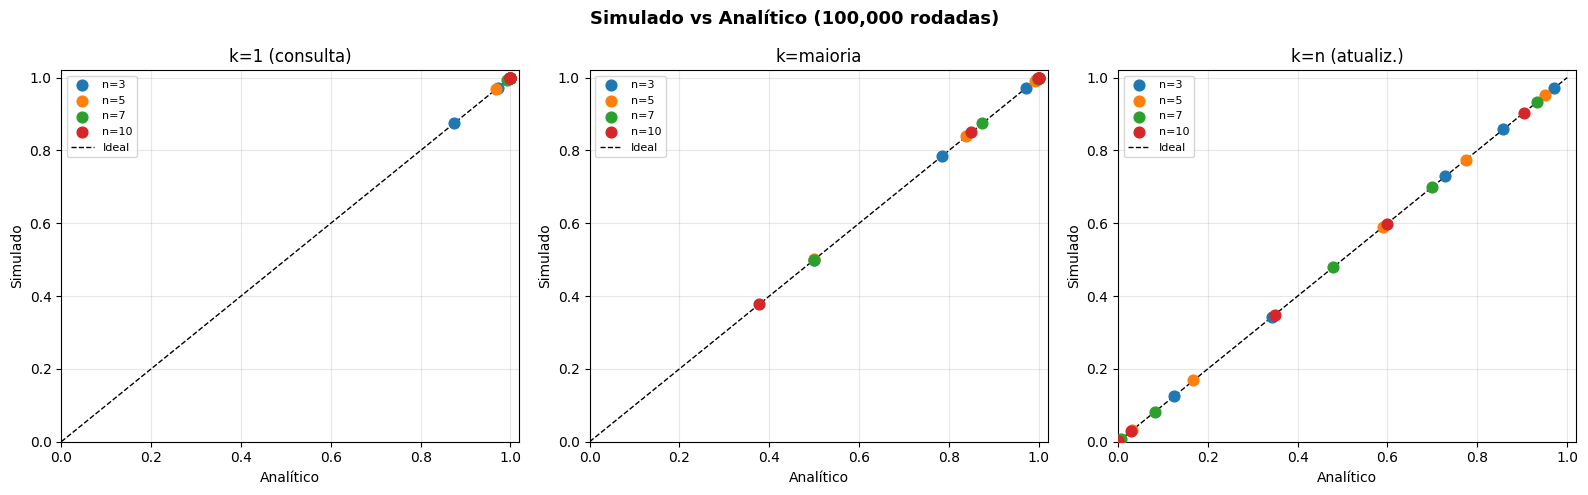

In [21]:
# Dispersão: simulado vs analítico (ponto ideal = diagonal)
k_tipos = ['k=1', 'k=maioria', 'k=n']
titles_k = ['k=1 (consulta)', 'k=maioria', 'k=n (atualiz.)']
colors_n = {3: 'tab:blue', 5: 'tab:orange', 7: 'tab:green', 10: 'tab:red'}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, k_tipo, title in zip(axes, k_tipos, titles_k):
    subset = df_comp[df_comp['k_tipo'] == k_tipo]
    for n_val, grp in subset.groupby('n'):
        ax.scatter(grp['Analítico'], grp['Simulado'],
                   label=f'n={n_val}', color=colors_n[n_val], s=60, zorder=5)
    ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Ideal')
    ax.set_xlim(0, 1.02); ax.set_ylim(0, 1.02)

    ax.set_xlabel('Analítico'); ax.set_ylabel('Simulado'); ax.set_title(title); ax.legend(fontsize=8)

plt.suptitle(f'Simulado vs Analítico ({RODADAS:,} rodadas)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

### Gráfico de Barras — Analítico vs Simulado (n = 5)

Para `n = 5`, as disponibilidades analítica e simulada são comparadas lado a lado para cada valor de `p` e cada política de quórum. Essa visualização facilita identificar se há viés sistemático do simulador em alguma faixa de `p` — barras de mesma altura indicam simulador preciso.

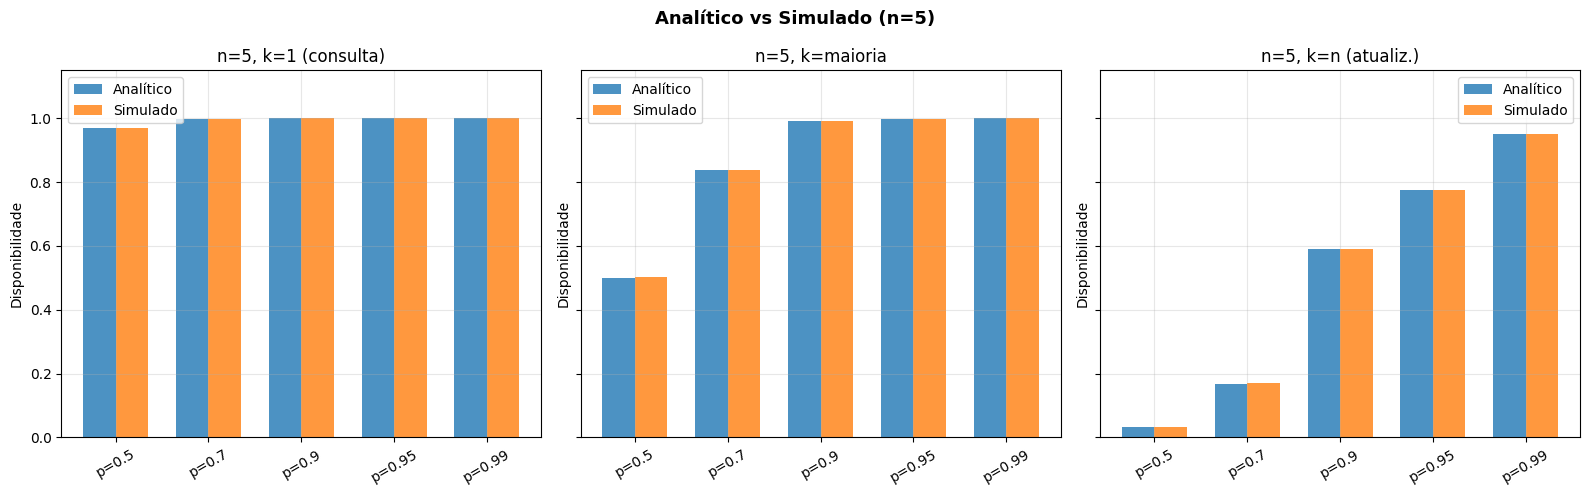

In [22]:
# Barras comparativas para n=5
df_n5 = df_comp[df_comp['n'] == 5]
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

for ax, k_tipo, title in zip(axes, k_tipos, titles_k):
    sub = df_n5[df_n5['k_tipo'] == k_tipo].sort_values('p')
    x = np.arange(len(sub)); w = 0.35
    ax.bar(x - w/2, sub['Analítico'], w, label='Analítico', color='tab:blue', alpha=0.8)
    ax.bar(x + w/2, sub['Simulado'],  w, label='Simulado',  color='tab:orange', alpha=0.8)
    ax.set_xticks(x); ax.set_xticklabels([f'p={v}' for v in sub['p']], rotation=30)
    ax.set_ylabel('Disponibilidade'); ax.set_title(f'n=5, {title}')
    ax.legend(); ax.set_ylim(0, 1.15)

plt.suptitle('Analítico vs Simulado (n=5)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

### Curvas Analítico vs Simulado — Variando p (n = 7)

Para `n = 7`, a **curva analítica contínua** é sobreposta aos **pontos simulados** (50.000 rodadas) ao longo de todo o intervalo `p ∈ [0,01; 0,99]`.

A sobreposição confirma que o simulador acompanha fielmente a curva teórica em toda a faixa de `p` — inclusive nos extremos, onde a disponibilidade varia mais rapidamente e o risco de divergência é maior.

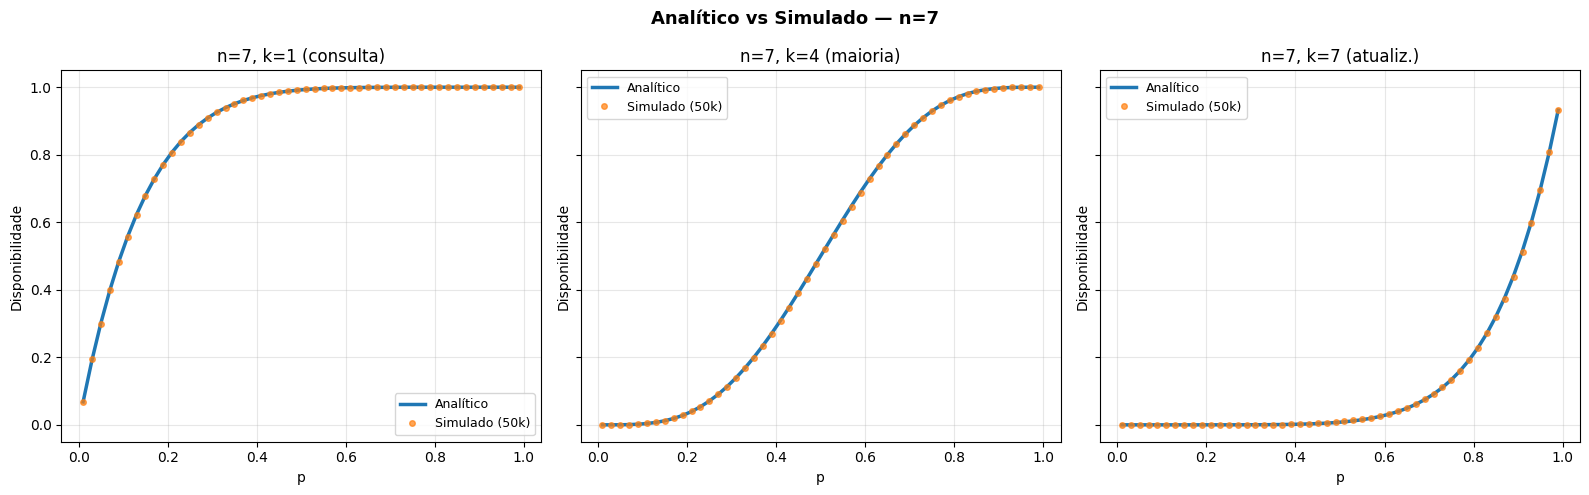

In [23]:
# Curvas analítico vs simulado variando p
p_range = np.linspace(0.01, 0.99, 50)
n_plot = 7
k_maioria_plot = n_plot // 2 + 1
ks_plot = [1, k_maioria_plot, n_plot]
titles_p = ['k=1 (consulta)', f'k={k_maioria_plot} (maioria)', f'k={n_plot} (atualiz.)']

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
for ax, k, title in zip(axes, ks_plot, titles_p):
    A_anal = [disponibilidade_analitica(n_plot, k, p) for p in p_range]
    A_sim  = [simular_disponibilidade(n_plot, k, p, rodadas=50_000, seed=99) for p in p_range]
    ax.plot(p_range, A_anal, '-',  color='tab:blue',   lw=2.5, label='Analítico')
    ax.plot(p_range, A_sim,  'o',  color='tab:orange', ms=4, alpha=0.7, label='Simulado (50k)')
    ax.set_title(f'n={n_plot}, {title}'); ax.set_xlabel('p'); ax.set_ylabel('Disponibilidade')
    ax.legend(fontsize=9)

plt.suptitle(f'Analítico vs Simulado — n={n_plot}', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

---
## Estudo Complementar — Quantos servidores são necessários quando p = 0,5 e k = 1?

Para operações de leitura, em que basta **ao menos um servidor** disponível, a fórmula se reduz a:

$$A(n,1,p)=1-(1-p)^n$$

Fixando $p=0{,}5$, obtemos:

$$A(n,1,0{,}5)=1-(0{,}5)^n$$

Deseja-se encontrar o menor valor de $n$ tal que a disponibilidade atinja cada meta especificada. Isso equivale a resolver:

$$1-(0{,}5)^n \geq \text{meta}$$

ou, de forma equivalente,

$$n \geq \frac{\ln(1-\text{meta})}{\ln(0{,}5)}$$

Como $n$ representa quantidade de servidores, toma-se o menor inteiro que satisfaz a desigualdade.

,Meta de disponibilidade,n mínimo,Disponibilidade obtida
0,90.0000%,4,0.937500
1,99.0000%,7,0.992188
2,99.9000%,10,0.999023
3,99.9900%,14,0.999939
4,99.9990%,17,0.999992
5,99.9999%,20,0.999999


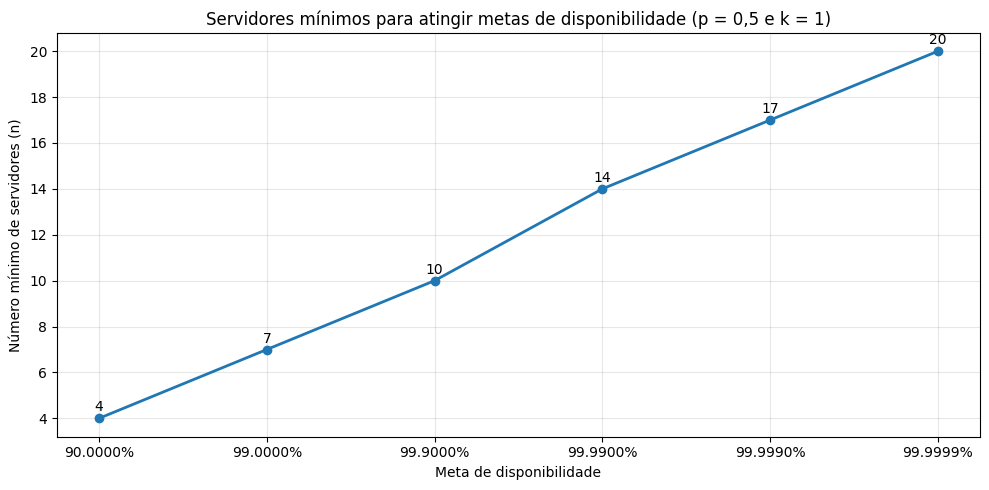

In [24]:
metas = [0.90, 0.99, 0.999, 0.9999, 0.99999, 0.999999]
rows_meta = []

p_meta = 0.5  # probabilidade individual de disponibilidade de cada servidor
k_meta = 1    # basta 1 servidor disponível (operação de leitura/consulta)

for meta in metas:
    # Resolve analiticamente: 1 - (1-p)^n >= meta  =>  n >= log(1-meta) / log(1-p)
    # math.ceil garante o menor inteiro que satisfaz a desigualdade
    n_min = math.ceil(math.log(1 - meta) / math.log(1 - p_meta))
    disponibilidade = disponibilidade_analitica(n_min, k_meta, p_meta)
    rows_meta.append({
        'Meta de disponibilidade': f'{meta*100:.4f}%',
        'n mínimo': n_min,
        'Disponibilidade obtida': round(disponibilidade, 10)
    })

df_metas = pd.DataFrame(rows_meta)
display(df_metas)

plt.figure(figsize=(10, 5))
plt.plot(df_metas['Meta de disponibilidade'], df_metas['n mínimo'], marker='o', linewidth=2)
plt.title('Servidores mínimos para atingir metas de disponibilidade (p = 0,5 e k = 1)')
plt.xlabel('Meta de disponibilidade')
plt.ylabel('Número mínimo de servidores (n)')
plt.grid(True, alpha=0.3)

# Anota o valor de n sobre cada ponto para facilitar a leitura
for i, row in df_metas.iterrows():
    plt.text(i, row['n mínimo'] + 0.3, str(row['n mínimo']), ha='center')

plt.tight_layout()
plt.show()

**Tabela 2 / Figura 3** — Quantidade mínima de servidores necessária para atingir metas de disponibilidade com p = 0,5 e k = 1. *Fonte: elaboração própria.*

A tabela e o gráfico respondem à seguinte pergunta: dado que cada servidor tem apenas 50% de chance de estar disponível em um dado instante, quantas réplicas são necessárias para que o serviço como um todo atinja uma determinada meta de disponibilidade?

A resposta vem da equação $A(n, 1, 0{,}5) = 1 - (0{,}5)^n \geq \text{meta}$, resolvida para n:

$$n \geq \frac{\ln(1 - \text{meta})}{\ln(0{,}5)}$$

O valor de n é então obtido pelo teto dessa expressão, garantindo que a disponibilidade calculada seja ao menos igual à meta desejada.

O resultado evidencia o poder da replicação mesmo quando cada nó individualmente é pouco confiável: com apenas 4 servidores já se ultrapassa 90% de disponibilidade; com 7 servidores chega-se a 99%; e para metas de cinco ou seis noves (99,999% e 99,9999%) bastam 17 e 20 servidores, respectivamente. Cada dígito de disponibilidade adicional exige aproximadamente 3 servidores a mais — relação que decorre diretamente da progressão geométrica de $(0{,}5)^n$.

---
## Resumo e Conclusões

### Fórmula geral derivada

$$A(n, k, p) = \sum_{i=k}^{n} \binom{n}{i} p^i (1-p)^{n-i}$$

Casos extremos: `k=1` → `A = 1-(1-p)^n` | `k=n` → `A = p^n`

---

### Interpretação do caso intermediário

Como `k` representa uma quantidade inteira de servidores, no caso intermediário foi adotado o quórum de maioria:

$$k = \left\lfloor \frac{n}{2} \right\rfloor + 1$$

Essa escolha evita ambiguidades quando `n` é ímpar e representa corretamente a ideia de maioria dos servidores disponíveis.

---

### Como os valores variam?

| Parâmetro | k=1 (consulta) | k=maioria | k=n (atualização) |
|-----------|-----------------|-----------|-------------------|
| ↑ p       | Sobe            | Sobe      | Sobe              |
| ↑ n       | **Sobe** (redundância ajuda) | depende do valor de p e do quórum | **Cai** (mais chances de falha total) |
| ↑ k       | mais exigente → disponibilidade menor | — | — |

---

### Convergência do simulador

Nos cenários testados, o erro do simulador decai aproximadamente como **1/√R**, conforme esperado em métodos de Monte Carlo. Poucas centenas de rodadas ainda produzem oscilações visíveis, enquanto **10.000 a 100.000 rodadas** já fornecem excelente concordância com o valor analítico.

---

### Resultado complementar para p = 0,5 e k = 1

Com disponibilidade individual de apenas 50% por servidor, o aumento do número de réplicas melhora rapidamente a disponibilidade do serviço. Para atingir metas de **90%**, **99%**, **99,9%**, **99,99%**, **99,999%** e **99,9999%**, são necessários respectivamente **4, 7, 10, 14, 17 e 20 servidores**.

---

### Conclusão

O simulador confirma a fórmula analítica em todos os cenários testados. A replicação é especialmente vantajosa quando `k=1`, pois basta uma réplica disponível para o serviço permanecer acessível. O caso `k=n` é o mais restritivo e apresenta a menor disponibilidade, pois qualquer falha individual derruba o sistema. O quórum de maioria (`k = ⌊n/2⌋ + 1`) representa um compromisso intermediário entre disponibilidade e consistência. Por fim, a análise com `p=0,5` demonstra que a redundância eleva significativamente a disponibilidade mesmo quando cada servidor individual é confiável apenas pela metade.